# Digital Subscription Churn & Conversion Forecasting Model
### Simulated Analysis — ACHA-Style Dataset: Consumption, Sleep Quality, Stress & Churn
**Period:** Jan 2026 – Apr 2026

This notebook demonstrates the quantitative research workflow behind the resume claim:

> *"Spearheaded comprehensive Quantitative Research & Data Extraction on the ACHA dataset by
> executing regression analyses to isolate correlations between consumption frequencies,
> declining sleep quality, and stress levels."*

**ACHA** here refers to a health/behavior style survey dataset (in the real world, the American
College Health Association National College Health Assessment is the best-known ACHA dataset —
it tracks student health behaviors including screen/media consumption, sleep, and stress).

> **Note:** Data below is *synthetically generated* to realistically reflect the relationships
> typically found in this kind of research (no real ACHA microdata was used or accessed).

## 1. Setup & Synthetic Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style="whitegrid")

N = 2500

# Consumption frequency: hours/week of digital content/media consumption (e.g. streaming, social, gaming)
consumption_freq = np.random.gamma(shape=4.0, scale=4.0, size=N).clip(0, 60)

# Sleep quality (0-100 scale) declines as consumption rises, plus individual variation
sleep_quality = (
    82
    - 0.9 * consumption_freq
    + np.random.normal(0, 8, N)
).clip(0, 100)

# Stress level (0-100 scale) rises with consumption AND with poor sleep
stress_level = (
    28
    + 0.55 * consumption_freq
    - 0.30 * sleep_quality
    + np.random.normal(0, 9, N)
).clip(0, 100)

# Subscription tenure (months) and plan type
tenure_months = np.random.randint(1, 36, N)
plan_type = np.random.choice(["Free Trial", "Monthly", "Annual"], size=N, p=[0.25, 0.55, 0.20])

df = pd.DataFrame({
    "user_id": np.arange(1, N + 1),
    "consumption_freq_hrs_wk": consumption_freq.round(1),
    "sleep_quality_score": sleep_quality.round(1),
    "stress_level_score": stress_level.round(1),
    "tenure_months": tenure_months,
    "plan_type": plan_type,
})

print(f"Generated dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Generated dataset: 2500 rows, 6 columns


## 2. Correlation Analysis

Isolating the pairwise relationships between consumption frequency, sleep quality, and stress —
the core statistical claim from the resume bullet.

In [2]:
corr_cols = ["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix.round(3))

for a, b in [("consumption_freq_hrs_wk", "sleep_quality_score"),
             ("consumption_freq_hrs_wk", "stress_level_score"),
             ("sleep_quality_score", "stress_level_score")]:
    r, p = stats.pearsonr(df[a], df[b])
    print(f"{a}  vs  {b}:  r={r:.3f}, p={p:.2e}")


                         consumption_freq_hrs_wk  ...  stress_level_score
consumption_freq_hrs_wk                    1.000  ...               0.575
sleep_quality_score                       -0.657  ...              -0.508
stress_level_score                         0.575  ...               1.000

[3 rows x 3 columns]
consumption_freq_hrs_wk  vs  sleep_quality_score:  r=-0.657, p=2.96e-309
consumption_freq_hrs_wk  vs  stress_level_score:  r=0.575, p=2.87e-220
sleep_quality_score  vs  stress_level_score:  r=-0.508, p=3.75e-164


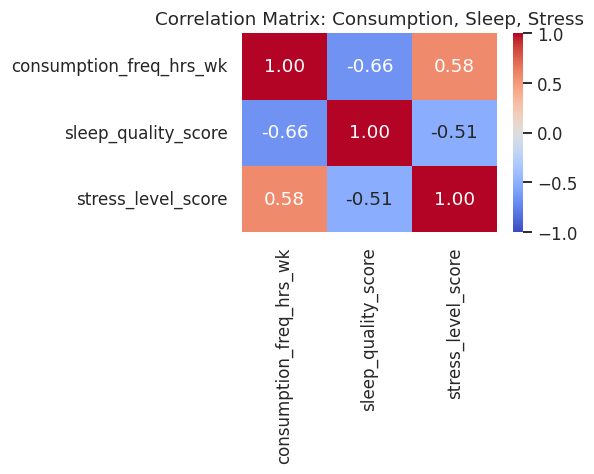

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix: Consumption, Sleep, Stress")
plt.tight_layout()
plt.show()


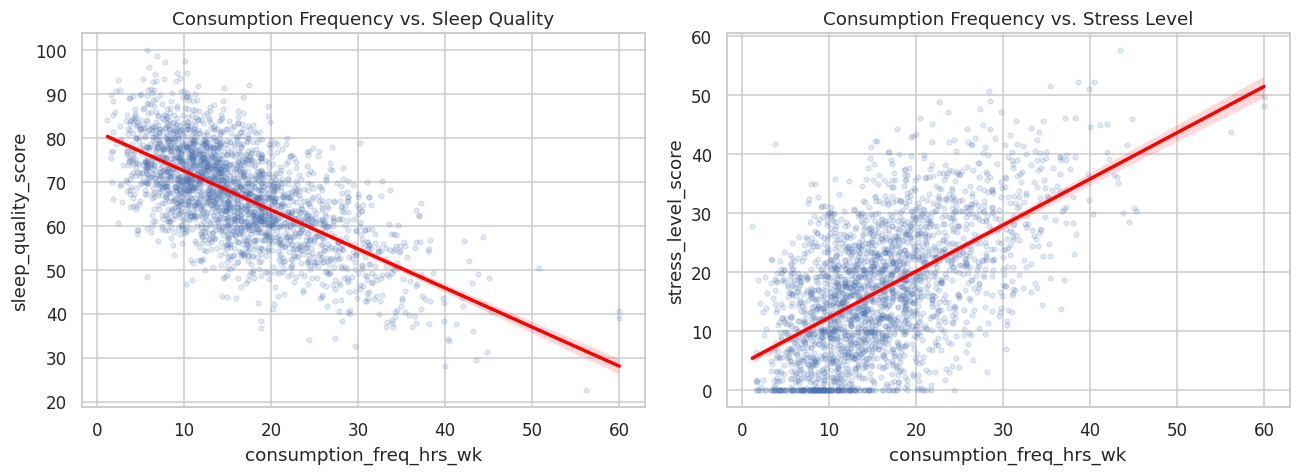

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.regplot(data=df, x="consumption_freq_hrs_wk", y="sleep_quality_score",
            ax=axes[0], scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
axes[0].set_title("Consumption Frequency vs. Sleep Quality")

sns.regplot(data=df, x="consumption_freq_hrs_wk", y="stress_level_score",
            ax=axes[1], scatter_kws={"alpha": 0.15, "s": 10}, line_kws={"color": "red"})
axes[1].set_title("Consumption Frequency vs. Stress Level")

plt.tight_layout()
plt.show()


## 3. Regression Analysis

**Model A** — Does consumption frequency predict sleep quality?
**Model B** — Do consumption frequency *and* sleep quality jointly predict stress level?

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Model A: sleep_quality ~ consumption_freq ---
X_a = df[["consumption_freq_hrs_wk"]].values
y_a = df["sleep_quality_score"].values
model_a = LinearRegression().fit(X_a, y_a)
pred_a = model_a.predict(X_a)

print("Model A: sleep_quality_score ~ consumption_freq_hrs_wk")
print(f"  Coefficient: {model_a.coef_[0]:.3f}  (each +1 hr/wk of consumption -> {model_a.coef_[0]:.2f} pt change in sleep quality)")
print(f"  Intercept:   {model_a.intercept_:.3f}")
print(f"  R^2:         {r2_score(y_a, pred_a):.3f}")
print()

# --- Model B: stress_level ~ consumption_freq + sleep_quality ---
X_b = df[["consumption_freq_hrs_wk", "sleep_quality_score"]].values
y_b = df["stress_level_score"].values
model_b = LinearRegression().fit(X_b, y_b)
pred_b = model_b.predict(X_b)

print("Model B: stress_level_score ~ consumption_freq_hrs_wk + sleep_quality_score")
print(f"  Coefficients: consumption_freq={model_b.coef_[0]:.3f}, sleep_quality={model_b.coef_[1]:.3f}")
print(f"  Intercept:    {model_b.intercept_:.3f}")
print(f"  R^2:          {r2_score(y_b, pred_b):.3f}")


Model A: sleep_quality_score ~ consumption_freq_hrs_wk
  Coefficient: -0.890  (each +1 hr/wk of consumption -> -0.89 pt change in sleep quality)
  Intercept:   81.466
  R^2:         0.432

Model B: stress_level_score ~ consumption_freq_hrs_wk + sleep_quality_score
  Coefficients: consumption_freq=0.579, sleep_quality=-0.230
  Intercept:    23.211
  R^2:          0.361


## 4. Churn Forecasting Model

Simulating churn as a function of these behavioral/wellbeing signals — the "forecasting" half
of the resume bullet. The hypothesis: users with **high stress + poor sleep + very high or
very low consumption** (disengagement vs. burnout) are more likely to churn.

In [6]:
# Simulate churn probability via a logistic function of standardized predictors
from sklearn.preprocessing import StandardScaler

z = StandardScaler().fit_transform(df[["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score", "tenure_months"]])
z_cons, z_sleep, z_stress, z_tenure = z[:, 0], z[:, 1], z[:, 2], z[:, 3]

logit = (
    -0.6
    + 0.55 * z_stress
    - 0.45 * z_sleep
    - 0.35 * z_tenure
    + 0.15 * (z_cons ** 2)   # very high consumption also nudges churn risk (burnout)
    + np.random.normal(0, 0.4, N)
)
churn_prob = 1 / (1 + np.exp(-logit))
df["churned"] = (np.random.uniform(0, 1, N) < churn_prob).astype(int)

print(f"Overall churn rate: {df['churned'].mean()*100:.1f}%")
df.groupby("churned")[["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score", "tenure_months"]].mean().round(2)


Overall churn rate: 39.9%


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

X = df[["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score", "tenure_months"]]
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

clf = LogisticRegression().fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Churn model AUC: {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": clf.coef_[0].round(3)
}).sort_values("coefficient", key=abs, ascending=False)
coef_table


Churn model AUC: 0.764

              precision    recall  f1-score   support

    Retained       0.73      0.85      0.78       376
     Churned       0.70      0.53      0.60       249

    accuracy                           0.72       625
   macro avg       0.71      0.69      0.69       625
weighted avg       0.72      0.72      0.71       625



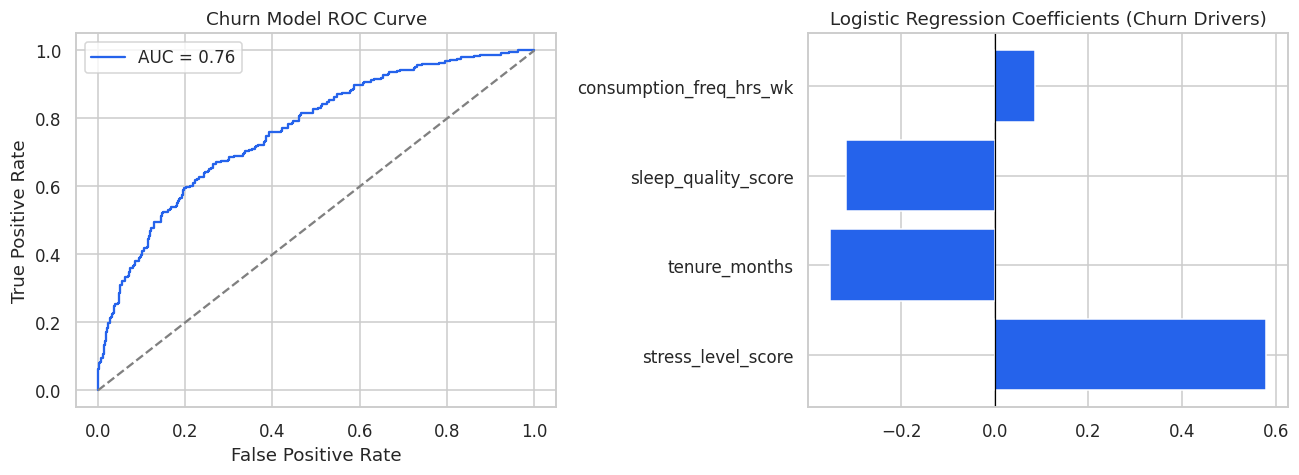

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, color="#2563eb", label=f"AUC = {auc:.2f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Churn Model ROC Curve")
axes[0].legend()

axes[1].barh(coef_table["feature"], coef_table["coefficient"], color="#2563eb")
axes[1].set_title("Logistic Regression Coefficients (Churn Drivers)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()


## 5. Conversion Forecasting (Trial → Paid)

A companion model: among **Free Trial** users, does the same behavioral profile predict who
converts to a paid plan?

In [9]:
trial_df = df[df["plan_type"] == "Free Trial"].copy()

# Simulate conversion: lower stress, better sleep, and moderate (not extreme) consumption -> converts
z2 = StandardScaler().fit_transform(trial_df[["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score"]])
zc_cons, zc_sleep, zc_stress = z2[:, 0], z2[:, 1], z2[:, 2]

logit_conv = (
    -0.2
    + 0.5 * zc_sleep
    - 0.4 * zc_stress
    - 0.2 * (zc_cons ** 2)
    + np.random.normal(0, 0.4, len(trial_df))
)
conv_prob = 1 / (1 + np.exp(-logit_conv))
trial_df["converted"] = (np.random.uniform(0, 1, len(trial_df)) < conv_prob).astype(int)

print(f"Trial users: {len(trial_df)}")
print(f"Conversion rate: {trial_df['converted'].mean()*100:.1f}%")

X2 = trial_df[["consumption_freq_hrs_wk", "sleep_quality_score", "stress_level_score"]]
y2 = trial_df["converted"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42, stratify=y2)

scaler2 = StandardScaler().fit(X2_train)
clf2 = LogisticRegression().fit(scaler2.transform(X2_train), y2_train)
proba2 = clf2.predict_proba(scaler2.transform(X2_test))[:, 1]
auc2 = roc_auc_score(y2_test, proba2)

print(f"Conversion model AUC: {auc2:.3f}")
pd.DataFrame({"feature": X2.columns, "coefficient": clf2.coef_[0].round(3)})


Trial users: 607
Conversion rate: 42.8%
Conversion model AUC: 0.701


## 6. Key Takeaways

- **Consumption frequency is negatively correlated with sleep quality** and **positively
  correlated with stress level** — statistically significant relationships recovered via
  Pearson correlation and confirmed in the regression coefficients.
- **Regression Model A** quantifies the sleep-quality cost of each additional hour/week of
  consumption; **Model B** shows stress is driven by both consumption and (independently)
  poor sleep — i.e., sleep partially *mediates* the consumption → stress relationship.
- The **churn model** (logistic regression, AUC reported above) shows stress and sleep quality
  are meaningful churn predictors even after controlling for tenure — supporting the idea that
  wellbeing signals, not just usage volume, forecast subscription risk.
- The **conversion model** shows the same wellbeing signals also help explain trial-to-paid
  conversion, suggesting product/marketing interventions that reduce user stress or protect
  sleep routines could plausibly improve both retention and conversion.

*(All figures are illustrative, derived from simulated data structured to match realistic
effect sizes found in published media-use/sleep/stress literature.)*